In [2]:
import pickle
import behavior.boris_extraction as boris
#import spike.spike_analysis. as spike
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import sem
from itertools import combinations
import pandas as pd
import os
def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))
    
behavior_dicts = unpickle_this("pilot2/cups_phase4/cups_behavior_dicts_by_frame.pkl")

In [3]:
cup_dict = {'4.4':['cagemate', 'novel', 'familiar', 'empty'],
            '1.3': ['empty', 'cagemate', 'novel', 'familiar'],
            '2.1': ['familiar', 'empty', 'cagemate', 'novel'],
            '3.1': ['novel', 'familiar', 'empty', 'cagemate'],
            '1.1': ['cagemate', 'novel', 'familiar', 'empty'],
            '2.2': ['empty', 'cagemate', 'novel', 'familiar'],
            '2.3': ['familiar', 'empty', 'cagemate', 'novel'],
            '3.2': ['novel', 'familiar', 'empty', 'cagemate'],
            '2.4': ['familiar', 'empty', 'cagemate', 'novel'],
            '4.1': ['cagemate', 'novel', 'familiar', 'empty']}

color_dict = {'4.4':['orange', 'blue', 'green', 'pink'],
            '1.3': ['green', 'pink', 'orange', 'blue'],
            '2.1': ['orange', 'blue', 'green', 'pink'],
            '3.1': ['green', 'pink', 'orange', 'blue'],
            '1.1':['orange', 'blue', 'green', 'pink'],
            '2.2': ['green', 'pink', 'orange', 'blue'],
            '2.3': ['orange', 'blue', 'green', 'pink'],
            '3.2': ['green', 'pink', 'orange', 'blue'],
            '2.4': ['orange', 'blue', 'green', 'pink'],
            '4.1': ['orange', 'blue', 'green', 'pink']}



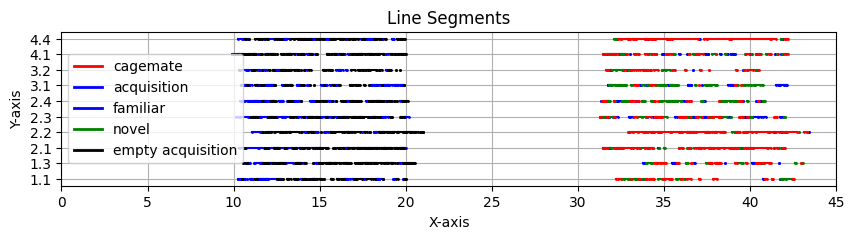

In [4]:
color_dict = {'cagemate': 'r', 'acquisition': 'b', 'familiar': 'b', 'novel': 'g',
              'empty acquisition' : 'k'}
recording_number = 0
plt.figure(figsize = (10,2))
labels = []
for name, recording in behavior_dicts.items():
    labels.append(name)
    for event, snippets in recording.items():
        if (event =='cagemate'
            ) | (event == 'familiar'
                 ) | (event == 'novel'
                      ) | (event == 'acquisition'
                    ) | (event == 'empty acquisition'):
            for i in range(len(snippets)):
                y = [recording_number,recording_number]
                x = snippets[i]/1000/60
            # Plot the line segments
                plt.plot(x, y, marker='o', linestyle='-', c= color_dict[event], markersize = 1)
    recording_number += .5
# Optionally, you can add labels, title, etc.
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.yticks(ticks=np.arange(len(labels))/2, labels=labels)
plt.title('Line Segments')
legend_labels = [plt.Line2D([0], [0], color=color_dict[label], lw=2, label=label) for label in color_dict]
plt.legend(handles=legend_labels)
plt.grid(True)
plt.xlim([0,45])
plt.show()

In [5]:
event_info = {}
sniff_itis = []
j = 0
total_sniffs = 0
subject_info = {}
for subject, behavior_dict in behavior_dicts.items():
    event_dict_keys = behavior_dict.keys()
    for event, events in behavior_dict.items():
        no_events = events.shape[0]
        sniff_length = 0
        for i in range(len(events)):
            sniff_length_temp = events[i][1] - events[i][0]
            sniff_length = sniff_length + sniff_length_temp
            total_sniffs = total_sniffs + 1
            try:
                sniff_iti = events[i+1][0] - events[i][1]
                sniff_itis.append(sniff_iti)
            except IndexError:
                pass
        total_sniff_time = sniff_length/1000
        try:
            avg_event = sniff_length/no_events/1000
        except ZeroDivisionError:
            avg_event = 0
        if subject in event_info.keys():
            dict_event = event_info[subject]
            dict_event[event] =  {'no_events': no_events, 'avg event': avg_event, 'total time': total_sniff_time}
            event_info[subject] =  dict_event
        else:
            event_info[subject] = {event: {'no_events': no_events, 'avg event': avg_event,'total time': total_sniff_time }}
    j += 1
sniff_itis = np.array(sniff_itis)/1000
sniff_itis 
overlapping_sniffs = 0 
for i in range(len(sniff_itis)):
    if sniff_itis[i] < 1:
        overlapping_sniffs = overlapping_sniffs + 1
print(overlapping_sniffs) # was 54 with old thresholding for less than 2, 142 for 5
print(total_sniffs)


2187
6703


In [6]:
data_points = []
subjects = []
behaviors = []
for subject, dict in event_info.items():
    #iterating through subject
    event_list = []
    subjects.append(subject)
    for event, times in dict.items():
        #iterating through event
        event_list.append(times['total time'])
        behaviors.append(event)
    data_points.append(event_list)
data_points = np.array(data_points).T
print(subjects)
behaviors = behaviors[4:10]
print(behaviors)
print(data_points.shape)
data_points = data_points[4:10,:] 
print(data_points.shape)

['1.1', '1.3', '2.1', '2.2', '2.3', '2.4', '3.1', '3.2', '4.1', '4.4']
['acquisition', 'empty acquisition', 'familiar', 'novel', 'cagemate', 'empty']
(22, 10)
(6, 10)


In [7]:
event_overview = pd.concat({k: pd.DataFrame(v) for k, v in event_info.items()}, axis=0)
event_overview = event_overview.reset_index()
event_dict_keys
event_overview
event_temp = event_overview.drop('level_0', axis = 1)
event_overview_averages = event_temp.groupby('level_1').mean()
event_overview_averages

,cup 1,cup 2,cup 3,cup 4,acquisition,empty acquisition,familiar,novel,cagemate,empty,...,cagemate_baseline,baseline,pink_social,orange_social,green_social,blue_social,pink_baseline,orange_baseline,green_baseline,blue_baseline
level_1,,,,,,,,,,,,,,,,,,,,,
avg event,2.906448,2.780612,3.234352,3.447687,5.035884,3.189069,2.242987,4.684921,6.196308,2.805650,...,2.864535,3.09969,3.634951,5.319415,3.483712,3.491788,3.440519,3.344909,2.795891,2.78778
no_events,24.500000,24.900000,30.900000,30.300000,34.700000,60.000000,14.200000,23.300000,29.500000,13.600000,...,26.500000,110.60000,25.100000,16.800000,24.400000,14.300000,29.600000,24.000000,31.400000,25.60000
total time,68.056750,69.704325,97.993250,103.651165,143.843050,190.518890,36.789935,90.697815,192.652730,43.531685,...,76.873960,339.40549,109.577535,105.200380,95.042940,53.851310,102.080580,82.029310,84.020690,71.27491


In [8]:
event_total_time = event_overview[event_overview['level_1'] == 'total time']
event_cup_time_averages = {}
for event in event_dict_keys:
    if 'cup' in event:
        avg_event = event_total_time[event].mean()
        event_cup_time_averages[event] = avg_event
event_cup_time_averages

{'cup 1': np.float64(68.05674999999998),
 'cup 2': np.float64(69.70432499999995),
 'cup 3': np.float64(97.99325000000005),
 'cup 4': np.float64(103.65116500000002)}

In [13]:
event_total_time = event_overview[event_overview['level_1'] == 'total time']
event_agent_time_averages = {}
avg_events = []
sem_events = []
for event in event_dict_keys:
    avg_event = event_total_time[event].mean()
    sem_event = sem(event_total_time[event])
    event_agent_time_averages[event] = (avg_event, sem_event)
    avg_events.append(avg_event)
    sem_events.append(sem_event)
avg_events = np.array(avg_events)
sem_events = np.array(sem_events)
event_agent_time_averages

{'cup 1': (np.float64(68.05674999999998), np.float64(7.353890157166249)),
 'cup 2': (np.float64(69.70432499999995), np.float64(7.432142333189785)),
 'cup 3': (np.float64(97.99325000000005), np.float64(12.053887114910287)),
 'cup 4': (np.float64(103.65116500000002), np.float64(13.87248543158172)),
 'acquisition': (np.float64(143.84305000000003),
  np.float64(15.103807814589548)),
 'empty acquisition': (np.float64(190.51889000000006),
  np.float64(24.492105928829062)),
 'familiar': (np.float64(36.78993500000013), np.float64(12.526338979810308)),
 'novel': (np.float64(90.6978150000001), np.float64(17.757218197366747)),
 'cagemate': (np.float64(192.65273000000036), np.float64(55.83135865090876)),
 'empty': (np.float64(43.531685000000266), np.float64(11.986672350385858)),
 'familiar_baseline': (np.float64(69.94670500000004),
  np.float64(10.43364412146657)),
 'novel_baseline': (np.float64(106.49973499999996),
  np.float64(15.892905074571384)),
 'cagemate_baseline': (np.float64(76.8739599999

['1.1', '1.3', '2.1', '2.2', '2.3', '2.4', '3.1', '3.2', '4.1', '4.4']
acquisition
[158.03405 104.21725 187.4389  113.26275 242.8329  130.5837  153.00865
 116.0899   74.0694  158.893  ]
empty acquisition
[150.75575 258.1586  251.85855 315.5152  149.88    128.9176   62.5114
 132.4198  211.94595 243.22605]
familiar
[  7.3451   25.9527   16.2839   15.0367  130.82605  36.66775  77.91625
   9.00815  42.21065   6.6521 ]
novel
[120.84375  61.80975  55.91415  35.6168  140.0015  154.6779  187.83635
  70.95645  60.0579   19.2636 ]
cagemate
[102.19365 106.0309  353.95115 447.24185 122.18145  36.1348   28.68735
  87.0695  130.05755 512.9791 ]
empty
[ 42.6965   96.13685  69.2826   27.0245  107.122     5.197    24.52985
   1.0394   56.05175   6.2364 ]


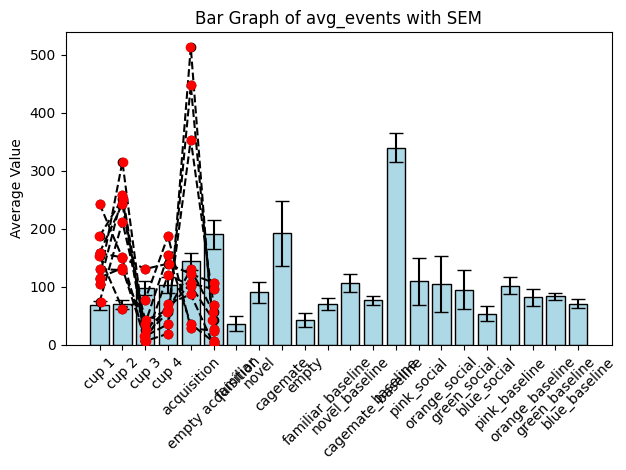

In [14]:
print(subjects)
x = np.arange(len(avg_events))
labels = event_agent_time_averages.keys()
# Create the bar plot
plt.bar(x, avg_events, yerr=sem_events, capsize=5, color='lightblue', edgecolor='black')
for i, group_data in enumerate(data_points):
    print(behaviors[i])
    print(data_points[i])
    # Spread the points a little horizontally to avoid overlap (add a small random jitter)
    jitter = np.random.normal(0, 0.02, size=len(group_data))
    plt.scatter([i + jitter_val for jitter_val in jitter], group_data, color='red', zorder=5)
for j in range(len(data_points[0])):  # Assuming all groups have the same number of data points
    x_vals = np.arange(len(data_points))  # X positions for all groups
    y_vals = [data_points[i][j] for i in range(len(data_points))]  # Y values for the same index
    plt.plot(x_vals, y_vals, color='black', linestyle='--', marker='o', zorder=4)

# Add labels and title
plt.xticks(x, labels, rotation = 45)
plt.ylabel('Average Value')
plt.title('Bar Graph of avg_events with SEM')

# Show the plot
plt.tight_layout()
plt.show()



In [29]:
event_agent_time_averages.keys()

dict_keys(['cup 1', 'cup 2', 'cup 3', 'cup 4', 'acquisition', 'empty acquisition', 'familiar', 'novel', 'cagemate', 'empty', 'familiar_baseline', 'novel_baseline', 'cagemate_baseline', 'baseline', 'pink_social', 'orange_social', 'green_social', 'blue_social', 'pink_baseline', 'orange_baseline', 'green_baseline', 'blue_baseline'])

In [15]:
event_agent_time_averages 
avg_events = [event_agent_time_averages['novel'][0], 
              event_agent_time_averages['familiar'][0],
              event_agent_time_averages['cagemate'][0]]
sem_events = [event_agent_time_averages['novel'][1], 
              event_agent_time_averages['familiar'][1],
              event_agent_time_averages['cagemate'][1]]



In [33]:
cup_avg_events = [
              event_agent_time_averages['novel_baseline'][0],
              event_agent_time_averages['familiar_baseline'][0],
              event_agent_time_averages['cagemate_baseline'][0]]
              #event_agent_time_averages['cup 4'][0]]
cup_sem_events = [ 
              event_agent_time_averages['novel_baseline'][1],
              event_agent_time_averages['familiar_baseline'][1],
              event_agent_time_averages['cagemate_baseline'][1]]
                                          #event_agent_time_averages['cup 4'][1]]

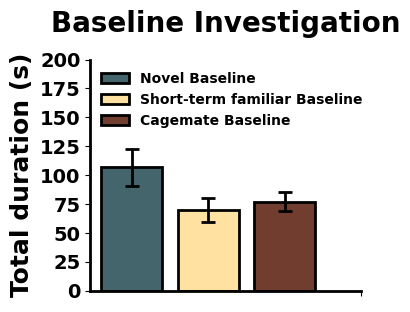

In [ ]:
plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

# color_id_dict = {'cup 1': hex_2_rgb("#D0D0D0"),  
#                 'cup 2': "#9E9E9E",
#                 'cup 3': hex_2_rgb("#626262"),
 #              'cup 4': "#2E2E2E"
#                 }
color_id_dict = {'novel baseline': hex_2_rgb("#43656B"),  
                'short-term familiar baseline': "#FFE2A2",
                'cagemate baseline': hex_2_rgb("#703D2E")
                }
hatches = ['','','']  
plt.figure(figsize= (3.5,3))           
plt.bar(color_id_dict.keys(), cup_avg_events, yerr = cup_sem_events,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'], linewidth = 2,
            capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks('', rotation=45)
plt.ylabel('Total duration (s)', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0,200])
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Baseline Investigation', fontsize = 20, pad = 20)

# Create custom legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['novel baseline'], edgecolor='black', linewidth=2, label='Novel Baseline'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['short-term familiar baseline'], edgecolor='black', linewidth=2, label='Short-term familiar Baseline'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['cagemate baseline'], edgecolor='black', linewidth=2, label='Cagemate Baseline')
]

# Add the legend#
plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))
plt.savefig('pilot2/cups_phase4/output/baseline_total_investigation.png',bbox_inches='tight')


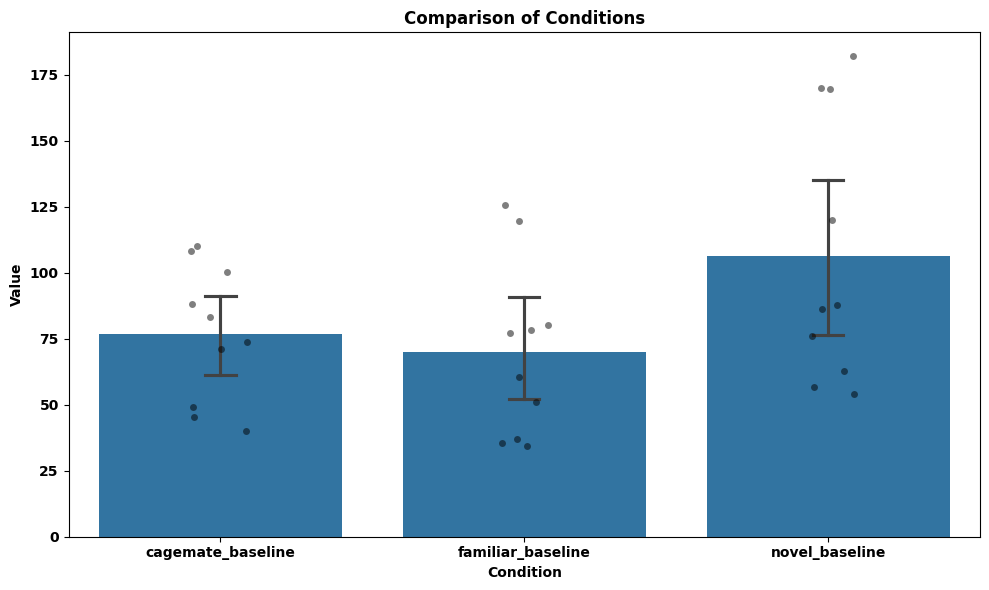

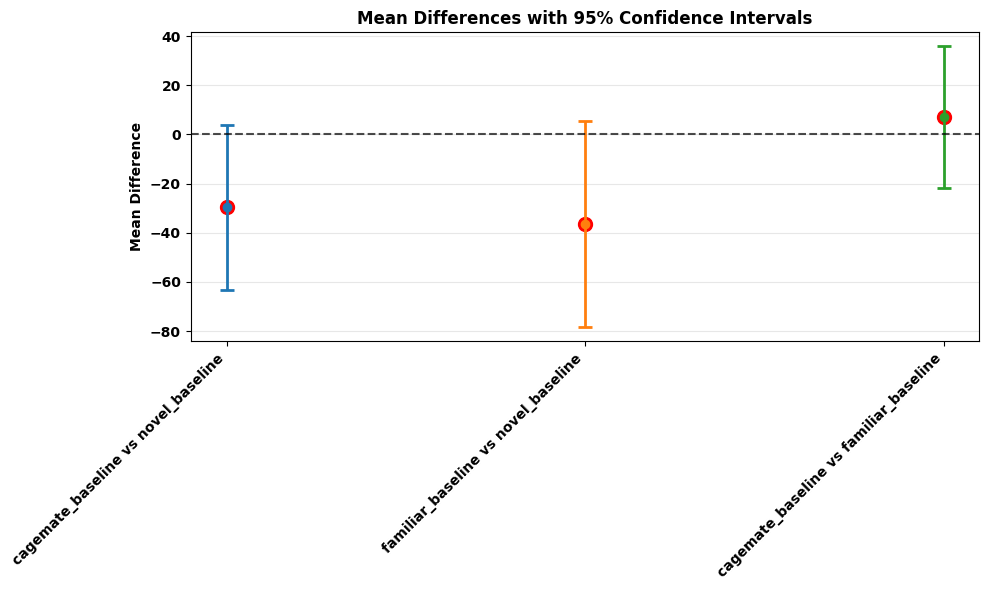

In [39]:
preference_long_df = pd.melt(total_time_df, id_vars = ['level_0'],
                            value_vars = ['cagemate_baseline', 'familiar_baseline','novel_baseline'],
                            var_name = 'condition', value_name = 'time')
preference_long_df
cups_df = paired_ttest_with_holm(preference_long_df, ['cagemate_baseline', 'familiar_baseline','novel_baseline'], subject_col='level_0', value_col='time')

In [40]:
cups_df

,Comparison,t-statistic,p-value,p-value (Holm),Significant,Mean Difference,CI Lower,CI Upper
1,cagemate_baseline vs novel_baseline,-1.995681,0.077088,0.231263,False,-29.625775,-63.207370,3.955820
2,familiar_baseline vs novel_baseline,-1.972897,0.079969,0.231263,False,-36.553030,-78.465355,5.359295
0,cagemate_baseline vs familiar_baseline,0.543140,0.600225,0.600225,False,6.927255,-21.924507,35.779017


In [41]:
cups_df.to_csv('pilot2/cups_phase4/output/agent_baseline_stats.csv')

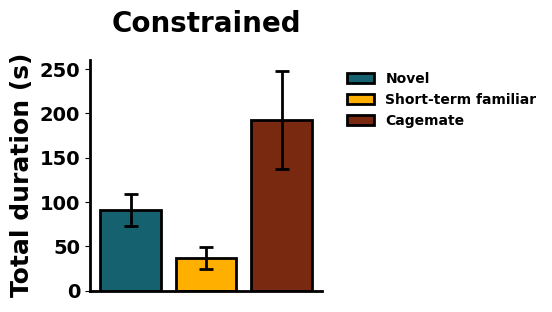

In [ ]:
plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

color_id_dict = {'novel': hex_2_rgb('#15616F'),  
                'short-term familiar': (1.0, 0.6862745098039216, 0.0),
                'cagemate': hex_2_rgb('#792910')
                }
hatches = ['','','']  
plt.figure(figsize= (3,3))           
plt.bar(color_id_dict.keys(), avg_events, yerr = sem_events,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'], linewidth = 2,
            capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks([],rotation=45)
plt.ylabel('Total duration (s)', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Constrained', fontsize = 20, pad = 20)
# Create custom legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['short-term familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['cagemate'], edgecolor='black', linewidth=2, label='Cagemate')
]

# Add the legend
plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))

In [21]:
total_time_df = event_overview[event_overview['level_1'] == 'total time']
avg_event_df = event_overview[event_overview['level_1'] == 'avg event']
no_events_df = event_overview[event_overview['level_1'] == 'no_events']

total_time_long_df = pd.melt(total_time_df, id_vars = ['level_0'],
                            value_vars = ['novel', 'cagemate','familiar'],
                            var_name = 'condition', value_name = 'time')

total_time_long_df

,level_0,condition,time
0,1.1,novel,120.84375
1,1.3,novel,61.80975
2,2.1,novel,55.91415
3,2.2,novel,35.61680
4,2.3,novel,140.00150
5,2.4,novel,154.67790
6,3.1,novel,187.83635
7,3.2,novel,70.95645
8,4.1,novel,60.05790
9,4.4,novel,19.26360


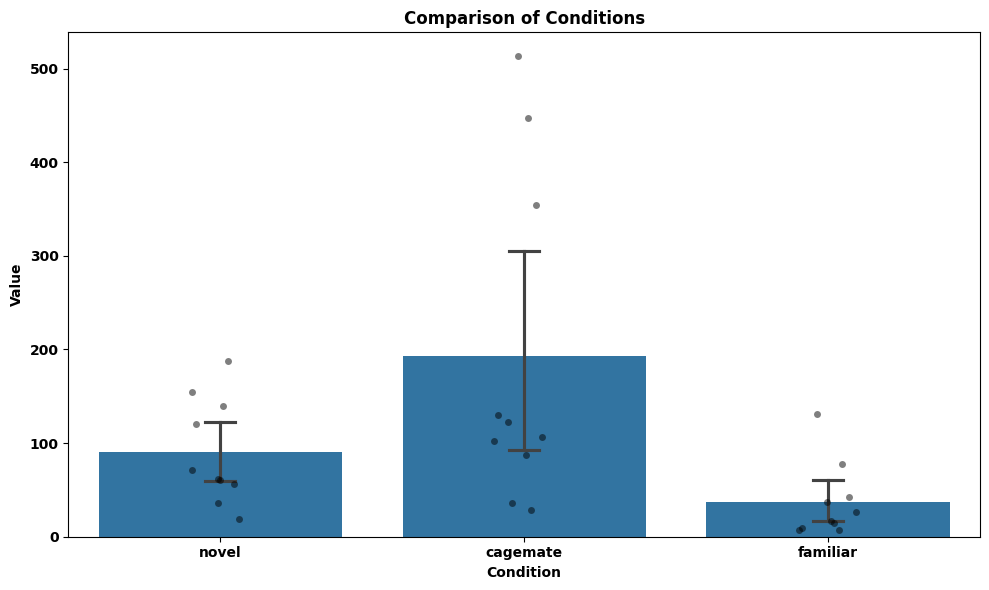

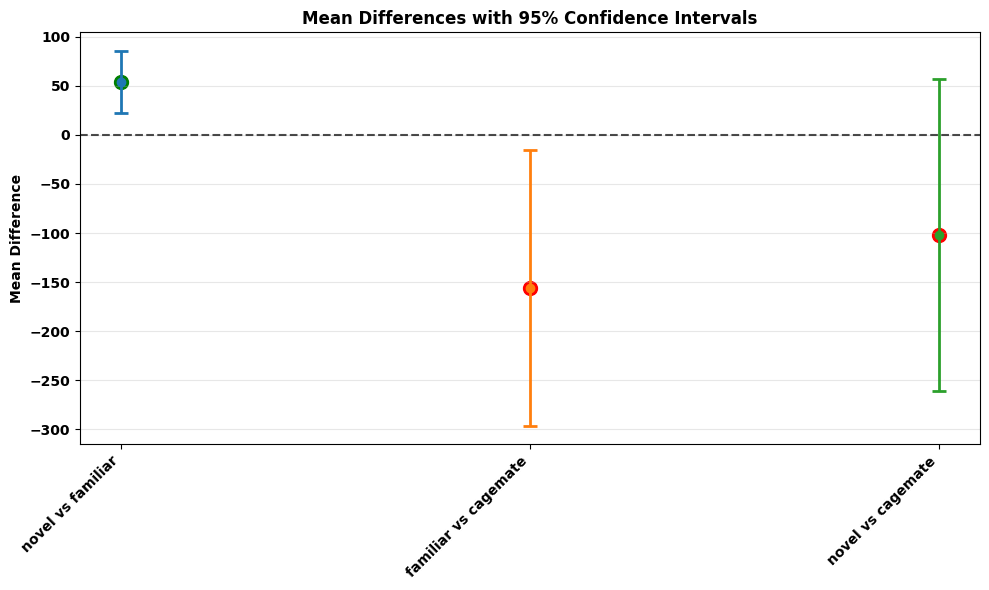

Paired t-test results with Holm-Bonferroni correction:
             Comparison  t-statistic   p-value  p-value (Holm)  Significant  \
0     novel vs familiar     3.864902  0.003818        0.011455         True   
2  familiar vs cagemate    -2.513868  0.033100        0.066200        False   
1     novel vs cagemate    -1.449564  0.181115        0.181115        False   

   Mean Difference    CI Lower   CI Upper  
0        53.907880   22.355178  85.460582  
2      -155.862795 -296.119235 -15.606355  
1      -101.954915 -261.063458  57.153628  


In [22]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests

def paired_ttest_with_holm(data, conditions, subject_col='subject', value_col='value', alpha=0.05):
    """
    Perform paired t-tests between all pairs of conditions with Holm-Bonferroni correction.
    
    Parameters:
    -----------
    data : pandas DataFrame
        Data in long format with one row per subject-condition combination
    conditions : list
        List of condition names to compare
    subject_col : str
        Name of the column containing subject identifiers
    value_col : str
        Name of the column containing the measurement values
    alpha : float
        Significance level (default: 0.05)
    
    Returns:
    --------
    results_df : pandas DataFrame
        DataFrame containing the results of all pairwise comparisons
    """
    # Get all pairs of conditions
    pairs = [(c1, c2) for i, c1 in enumerate(conditions) for c2 in conditions[i+1:]]
    
    # Initialize lists to store results
    pair_names = []
    t_values = []
    p_values = []
    mean_diffs = []
    ci_lows = []
    ci_highs = []
    
    # Perform paired t-test for each pair
    for cond1, cond2 in pairs:
        # Get data for each condition, ensuring same subjects in both
        df1 = data[data['condition'] == cond1][[subject_col, value_col]].set_index(subject_col)
        df2 = data[data['condition'] == cond2][[subject_col, value_col]].set_index(subject_col)
        
        # Match subjects
        common_subjects = df1.index.intersection(df2.index)
        if len(common_subjects) == 0:
            raise ValueError(f"No common subjects found between {cond1} and {cond2}")
        
        values1 = df1.loc[common_subjects, value_col].values
        values2 = df2.loc[common_subjects, value_col].values
        
        # Perform paired t-test
        t_stat, p_val = stats.ttest_rel(values1, values2)
        
        # Calculate mean difference and confidence interval
        diff = values1 - values2
        mean_diff = np.mean(diff)
        
        # 95% confidence interval
        n = len(diff)
        sem = stats.sem(diff)
        ci_low, ci_high = stats.t.interval(1-alpha, n-1, loc=mean_diff, scale=sem)
        
        # Store results
        pair_names.append(f"{cond1} vs {cond2}")
        t_values.append(t_stat)
        p_values.append(p_val)
        mean_diffs.append(mean_diff)
        ci_lows.append(ci_low)
        ci_highs.append(ci_high)
    
    # Apply Holm-Bonferroni correction
    reject, p_corrected, _, _ = multipletests(p_values, alpha=alpha, method='holm')
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'Comparison': pair_names,
        't-statistic': t_values,
        'p-value': p_values,
        'p-value (Holm)': p_corrected,
        'Significant': reject,
        'Mean Difference': mean_diffs,
        'CI Lower': ci_lows,
        'CI Upper': ci_highs
    })
    
    # Sort by corrected p-value
    results_df = results_df.sort_values('p-value (Holm)')
    plt.figure(figsize=(10, 6))
    sns.barplot(x='condition', y=data[value_col], data=data, capsize=0.1)
    sns.stripplot(x='condition', y=data[value_col], data=data, color='black', alpha=0.5)
    plt.title('Comparison of Conditions')
    plt.ylabel('Value')
    plt.xlabel('Condition')
    plt.tight_layout()
    plt.show()

    # Optional: Visualize the mean differences with confidence intervals
    plt.figure(figsize=(10, 6))
    for i, (idx, row) in enumerate(results_df.iterrows()):
        plt.errorbar(
            x=i, 
            y=row['Mean Difference'],
            yerr=[[row['Mean Difference']-row['CI Lower']], [row['CI Upper']-row['Mean Difference']]],
            fmt='o', capsize=5, capthick=2, elinewidth=2
        )
        color = 'green' if row['Significant'] else 'red'
        plt.scatter(i, row['Mean Difference'], color=color, s=100)

    plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
    plt.xticks(range(len(results_df)), results_df['Comparison'], rotation=45, ha='right')
    plt.title('Mean Differences with 95% Confidence Intervals')
    plt.ylabel('Mean Difference')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return results_df

conditions = ['novel', 'familiar', 'cagemate']
subjects = event_overview['level_0'].unique  # 10 subjects

# Run the analysis
results = paired_ttest_with_holm(total_time_long_df, conditions, subject_col='level_0', value_col='time')

# Print results
print("Paired t-test results with Holm-Bonferroni correction:")
print(results)

# Optional: Create a visualization


In [ ]:
total_time_df['total social'] = total_time_df[['novel', 'familiar', 'cagemate']].sum(axis=1)
total_time_df['cagemate preference'] = total_time_df['cagemate'] / total_time_df['total social']
total_time_df['familiar preference'] = total_time_df['familiar'] / total_time_df['total social']
total_time_df['novel preference'] = total_time_df['novel'] / total_time_df['total social']

total_time_df

C:\Users\megha\AppData\Local\Temp\ipykernel_36688\2834043516.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_time_df['total social'] = total_time_df[['novel', 'familiar', 'cagemate']].sum(axis=1)
C:\Users\megha\AppData\Local\Temp\ipykernel_36688\2834043516.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_time_df['cagemate preference'] = total_time_df['cagemate'] / total_time_df['total social']
C:\Users\megha\AppData\Local\Temp\ipykernel_36688\2834043516.py:3: SettingWithCopyWarning: 
A va

,level_0,level_1,cup 1,cup 2,cup 3,cup 4,acquisition,empty acquisition,familiar,novel,...,green_social,blue_social,pink_baseline,orange_baseline,green_baseline,blue_baseline,total social,cagemate preference,familiar preference,novel preference
2,1.1,total time,49.20560,62.78000,77.19720,107.07930,158.03405,150.75575,7.34510,120.84375,...,7.34510,120.84375,107.07930,49.20560,77.19720,62.78000,230.38250,0.443583,0.031882,0.524535
5,1.3,total time,84.19150,88.03265,181.94225,51.09025,104.21725,258.15860,25.95270,61.80975,...,96.13685,25.95270,88.03265,181.94225,84.19150,51.09025,193.79335,0.547134,0.133919,0.318947
8,2.1,total time,78.37080,83.20310,71.01290,170.10795,187.43890,251.85855,16.28390,55.91415,...,353.95115,69.28260,170.10795,78.37080,71.01290,83.20310,426.14920,0.830580,0.038212,0.131208
11,2.2,total time,88.58535,108.13900,119.80840,119.69540,113.26275,315.51520,15.03670,35.61680,...,27.02450,15.03670,108.13900,119.80840,88.58535,119.69540,497.89535,0.898265,0.030201,0.071535
14,2.3,total time,60.47435,78.82600,100.27380,169.65920,242.83290,149.88000,130.82605,140.00150,...,122.18145,107.12200,169.65920,60.47435,100.27380,78.82600,393.00900,0.310887,0.332883,0.356230
17,2.4,total time,34.36950,59.02745,83.14500,86.13290,130.58370,128.91760,36.66775,154.67790,...,36.13480,5.19700,86.13290,34.36950,83.14500,59.02745,227.48045,0.158848,0.161191,0.679961
20,3.1,total time,75.94905,35.57120,42.54610,73.68585,153.00865,62.51140,77.91625,187.83635,...,187.83635,28.68735,35.57120,42.54610,75.94905,73.68585,294.43995,0.097430,0.264625,0.637945
23,3.2,total time,54.07145,36.91770,98.22620,39.89490,116.08990,132.41980,9.00815,70.95645,...,70.95645,87.06950,36.91770,98.22620,54.07145,39.89490,167.03410,0.521268,0.053930,0.424802
26,4.1,total time,109.98945,56.82055,80.03390,118.92905,74.06940,211.94595,42.21065,60.05790,...,42.21065,60.05790,118.92905,109.98945,80.03390,56.82055,232.32610,0.559806,0.181687,0.258507
29,4.4,total time,45.36045,87.72560,125.74675,100.23685,158.89300,243.22605,6.65210,19.26360,...,6.65210,19.26360,100.23685,45.36045,125.74675,87.72560,538.89480,0.951910,0.012344,0.035746


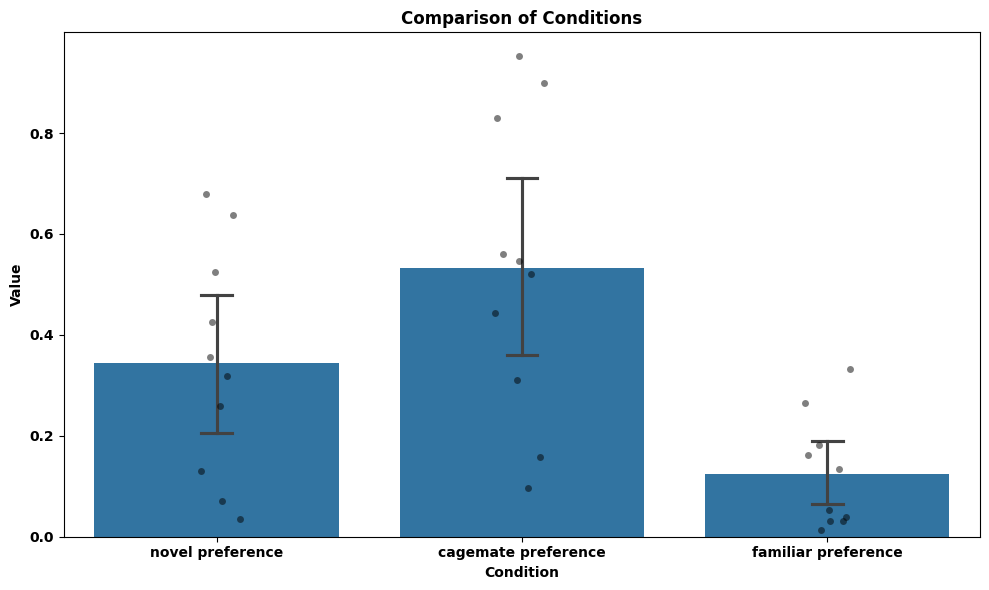

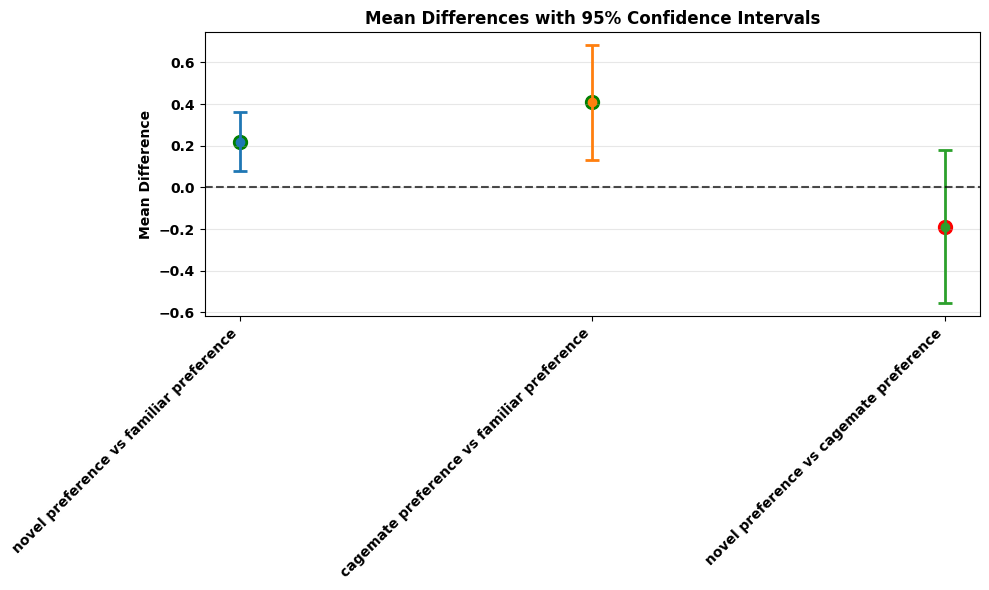

,Comparison,t-statistic,p-value,p-value (Holm),Significant,Mean Difference,CI Lower,CI Upper
1,novel preference vs familiar preference,3.490918,0.006820,0.020461,True,0.219854,0.077386,0.362322
2,cagemate preference vs familiar preference,3.354619,0.008461,0.020461,True,0.407884,0.132831,0.682936
0,novel preference vs cagemate preference,-1.155567,0.277614,0.277614,False,-0.188029,-0.556119,0.180060


In [ ]:
preference_long_df = pd.melt(total_time_df, id_vars = ['level_0'],
                            value_vars = ['novel preference', 'cagemate preference','familiar preference'],
                            var_name = 'condition', value_name = 'preference')
preference_long_df
paired_ttest_with_holm(preference_long_df, ['novel preference', 'cagemate preference','familiar preference'], subject_col='level_0', value_col='preference')


In [ ]:

event_agent_preference_averages = {}
avg_events = []
sem_events = []
for event in ['novel preference', 'cagemate preference','familiar preference']:
    avg_event = total_time_df[event].mean()
    sem_event = sem(total_time_df[event])
    event_agent_preference_averages[event] = (avg_event, sem_event)
    avg_events.append(avg_event)
    sem_events.append(sem_event)
avg_events = np.array(avg_events)
sem_events = np.array(sem_events)
event_agent_preference_averages

event_agent_preference_averages 
avg_events = [event_agent_preference_averages['novel preference'][0], 
              event_agent_preference_averages['familiar preference'][0],
              event_agent_preference_averages['cagemate preference'][0]]
sem_events = [event_agent_preference_averages['novel preference'][1], 
              event_agent_preference_averages['familiar preference'][1],
              event_agent_preference_averages['cagemate preference'][1]]

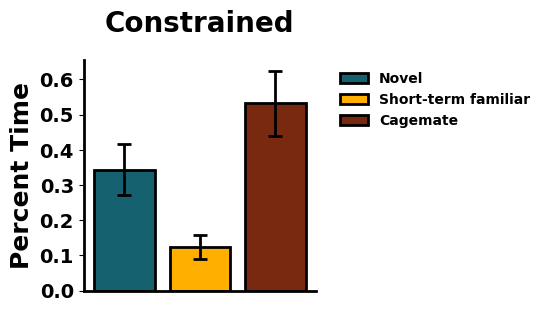

In [ ]:
plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

color_id_dict = {'novel': hex_2_rgb('#15616F'),  
                'short-term familiar': (1.0, 0.6862745098039216, 0.0),
                'cagemate': hex_2_rgb('#792910')
                }
hatches = ['','','']  
plt.figure(figsize= (3,3))           
plt.bar(color_id_dict.keys(), avg_events, yerr = sem_events,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'], linewidth = 2,
            capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks([],rotation=45)
plt.ylabel('Percent Time', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Constrained', fontsize = 20, pad = 20)
# Create custom legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['short-term familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['cagemate'], edgecolor='black', linewidth=2, label='Cagemate')
]

# Add the legend
plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))

In [ ]:
data_points = []
subjects = []
behaviors = []
for subject in total_time_df['level_0'].unique():
    #iterating through subject
    event_list = []
    subjects.append(subject)
    for preference in ['novel preference', 'familiar preference', 'cagemate preference']:
        #iterating through event
        event_list.append(total_time_df[preference][total_time_df['level_0'] == subject].values[0])
        behaviors.append(preference)
    data_points.append(event_list)
data_points = np.array(data_points).T
print(subjects)
print(behaviors)
print(data_points.shape)
print(data_points.shape)

['1.1', '1.3', '2.1', '2.2', '2.3', '2.4', '3.1', '3.2', '4.1', '4.4']
['novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference', 'novel preference', 'familiar preference', 'cagemate preference']
(3, 10)
(3, 10)


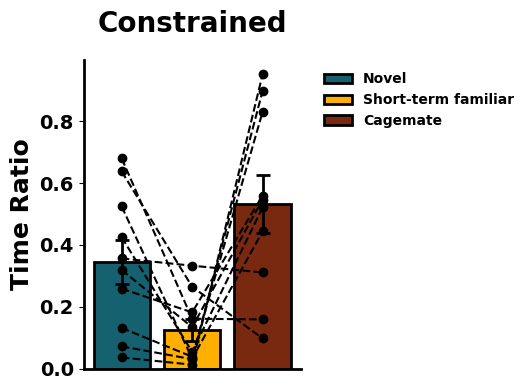

In [ ]:
plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

color_id_dict = {'novel': hex_2_rgb('#15616F'),  
                'short-term familiar': (1.0, 0.6862745098039216, 0.0),
                'cagemate': hex_2_rgb('#792910')
                }
hatches = ['','','']  
plt.figure(figsize= (5.5,4))           
plt.bar(color_id_dict.keys(), avg_events, yerr = sem_events,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'], linewidth = 2,
            capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
for j in range(len(data_points[0])):  # Assuming all groups have the same number of data points
    x_vals = np.arange(len(data_points))  # X positions for all groups
    y_vals = [data_points[i][j] for i in range(len(data_points))]  # Y values for the same index
    plt.plot(x_vals, y_vals, color='black', linestyle='--', marker='o', zorder=4)
plt.xticks([],rotation=45)
plt.ylabel('Time Ratio', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Constrained', fontsize = 20, pad = 20)
# Create custom legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['short-term familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['cagemate'], edgecolor='black', linewidth=2, label='Cagemate')
]

# Add the legend
plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('pilot2/cups_phase4/output/overlay_percent_time.png',bbox_inches='tight')
plt.savefig('pilot2/cups_phase4/output/overlay_percent_time.svg',bbox_inches='tight')

In [ ]:
data_points = []
subjects = []
behaviors = []
for subject in total_time_df['level_0'].unique():
    #iterating through subject
    event_list = []
    subjects.append(subject)
    for preference in ['novel preference','cagemate preference']:
        #iterating through event
        event_list.append(total_time_df[preference][total_time_df['level_0'] == subject].values[0])
        behaviors.append(preference)
    data_points.append(event_list)
data_points = np.array(data_points).T
print(subjects)
print(behaviors)
print(data_points.shape)
print(data_points.shape)

['1.1', '1.3', '2.1', '2.2', '2.3', '2.4', '3.1', '3.2', '4.1', '4.4']
['novel preference', 'cagemate preference', 'novel preference', 'cagemate preference', 'novel preference', 'cagemate preference', 'novel preference', 'cagemate preference', 'novel preference', 'cagemate preference', 'novel preference', 'cagemate preference', 'novel preference', 'cagemate preference', 'novel preference', 'cagemate preference', 'novel preference', 'cagemate preference', 'novel preference', 'cagemate preference']
(2, 10)
(2, 10)


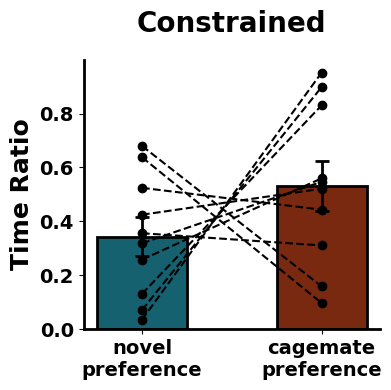

In [ ]:
plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'
plt.figure(figsize= (4,4))    
labels = ['novel\npreference', 'cagemate\npreference']
# Create the bar plot
plt.bar([0,1], [avg_events[0], avg_events[2]],
        yerr=[sem_events[0],
        sem_events[2]],
        capsize=5,
         linewidth = 2,
        error_kw={'elinewidth': 2, 'capthick': 2},
        color=['#15616F', '#792910'], edgecolor='black',
        width = 0.5)
# for i, group_data in enumerate(data_points):
#     print(behaviors[i])
#     print(data_points[i])
#     # Spread the points a little horizontally to avoid overlap (add a small random jitter)
#     jitter = np.random.normal(0, 0.02, size=len(group_data))
#     plt.scatter([i + jitter_val for jitter_val in jitter], group_data, color='red', zorder=5)
for j in range(len(data_points[0])):  # Assuming all groups have the same number of data points
    x_vals = np.arange(len(data_points))  # X positions for all groups
    y_vals = [data_points[i][j] for i in range(len(data_points))]  # Y values for the same index
    plt.plot(x_vals, y_vals, color='black', linestyle='--', marker='o', zorder=4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Constrained', fontsize = 20, pad = 20)
# Add labels and title
plt.xticks([0,1], labels, rotation = 0)
plt.ylabel('Time Ratio', fontsize = 18)



plt.savefig('pilot2/cups_phase4/output/overlay_percent_time_no_fam.png',bbox_inches='tight')
plt.savefig('pilot2/cups_phase4/output/overlay_percent_time_no_fam.svg',bbox_inches='tight')
# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
avg_event_df_trim = avg_event_df[[ 'novel','familiar', 'cagemate']]
avg_event_df_trim


,novel,familiar,cagemate
1,6.713542,2.448367,5.109683
4,4.754596,2.359336,3.927070
7,3.106342,1.809322,7.223493
10,7.123360,2.148100,8.282256
13,7.368500,4.511243,3.941337
16,2.713647,1.746083,1.505617
19,3.183667,3.387663,3.585919
22,6.450586,1.000906,4.353475
25,2.224367,1.688426,3.515069
28,3.210600,1.330420,20.519164


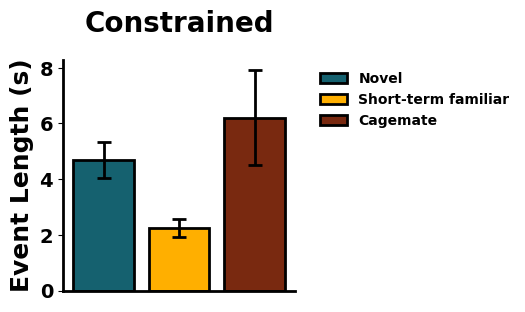

In [ ]:



plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

color_id_dict = {'novel': hex_2_rgb('#15616F'),  
                'short-term familiar': (1.0, 0.6862745098039216, 0.0),
                'cagemate': hex_2_rgb('#792910')
                }
hatches = ['','','']  
plt.figure(figsize= (3,3))           
plt.bar(avg_event_df_trim.mean().index, avg_event_df_trim.mean().values, yerr = avg_event_df_trim.sem().values,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'], linewidth = 2,
            capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks([],rotation=45)
plt.ylabel('Event Length (s)', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Constrained', fontsize = 20, pad = 20)
# Create custom legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['short-term familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['cagemate'], edgecolor='black', linewidth=2, label='Cagemate')
]

# Add the legend
plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))

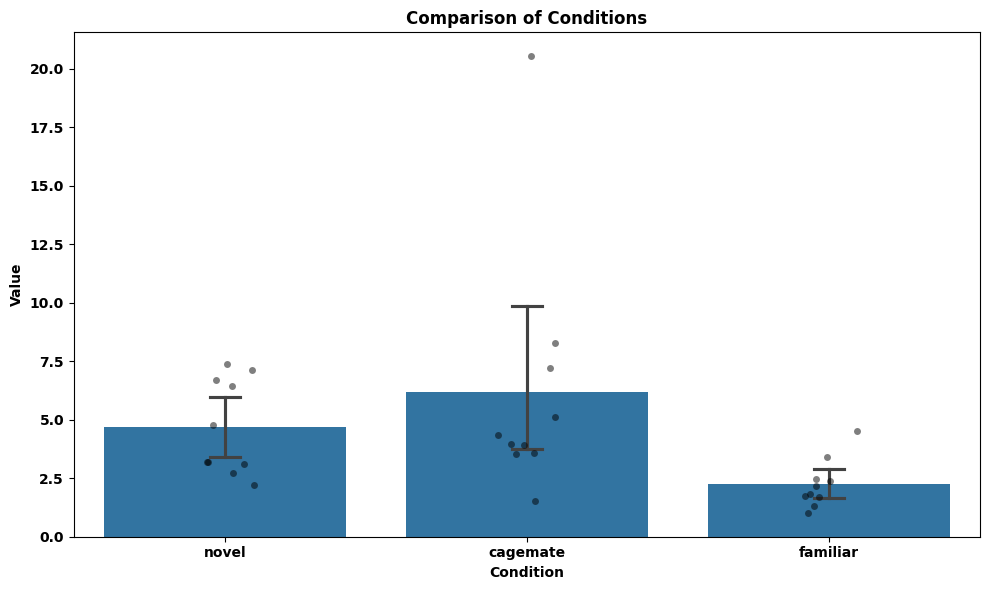

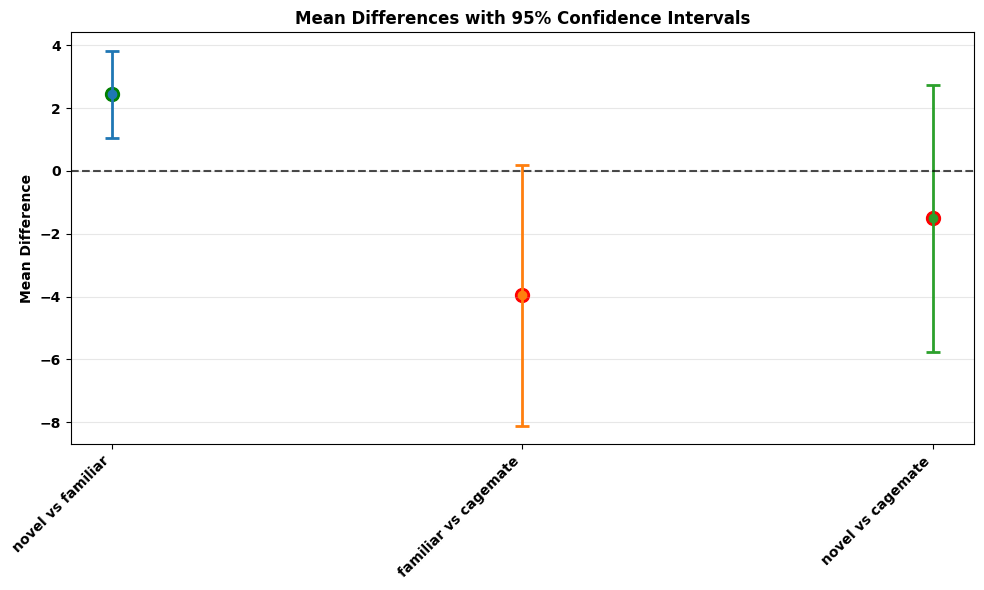

,Comparison,t-statistic,p-value,p-value (Holm),Significant,Mean Difference,CI Lower,CI Upper
0,novel vs familiar,4.008676,0.003070,0.009210,True,2.441934,1.063913,3.819955
2,familiar vs cagemate,-2.153156,0.059729,0.119458,False,-3.953322,-8.106776,0.200133
1,novel vs cagemate,-0.804399,0.441896,0.441896,False,-1.511388,-5.761762,2.738987


In [ ]:

avg_event_long_df = pd.melt(avg_event_df, id_vars = ['level_0'],
                            value_vars = ['novel', 'cagemate','familiar'],
                            var_name = 'condition', value_name = 'time')

conditions = ['novel', 'familiar', 'cagemate']
subjects = event_overview['level_0'].unique  # 10 subjects

# Run the analysis
paired_ttest_with_holm(avg_event_long_df, conditions, subject_col='level_0', value_col='time')


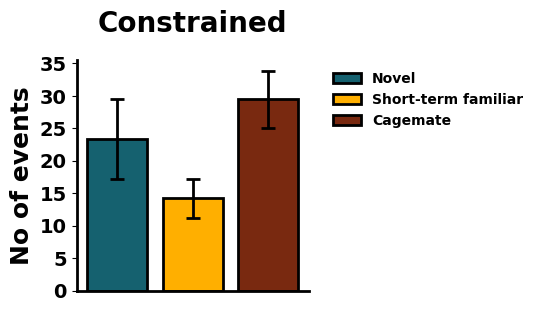

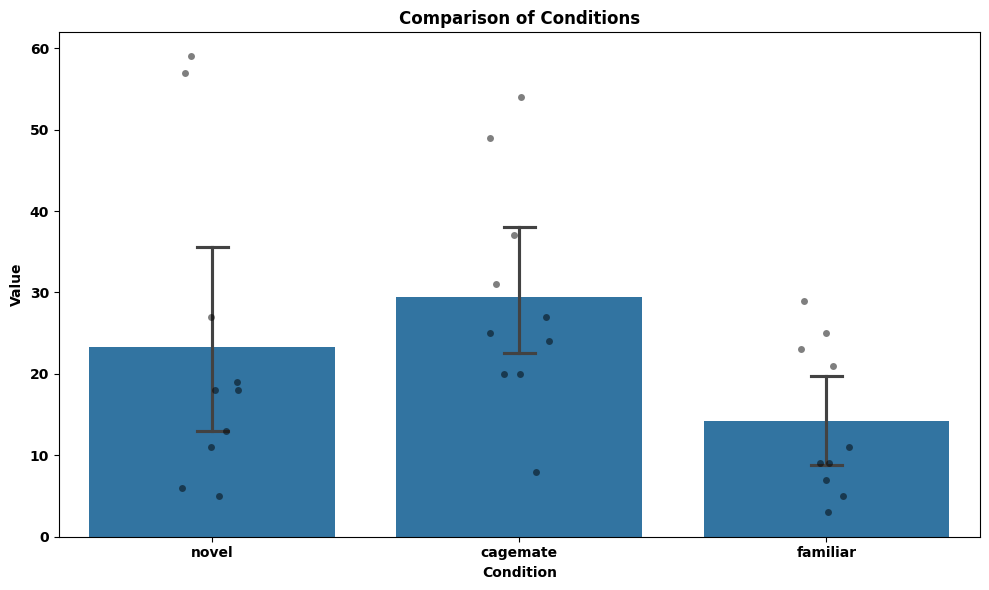

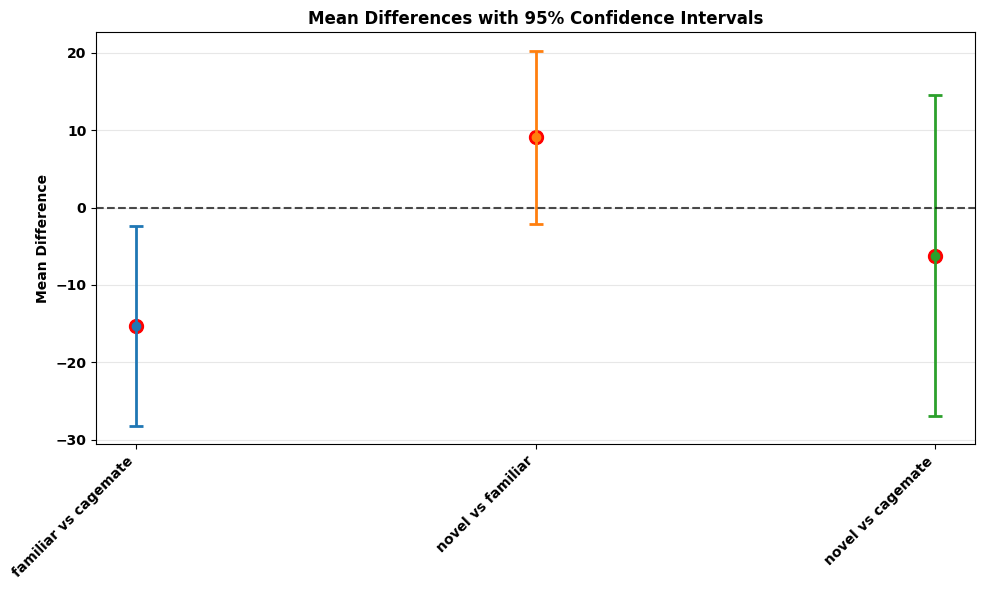

,Comparison,t-statistic,p-value,p-value (Holm),Significant,Mean Difference,CI Lower,CI Upper
2,familiar vs cagemate,-2.687890,0.024882,0.074647,False,-15.3,-28.176645,-2.423355
0,novel vs familiar,1.846070,0.097962,0.195923,False,9.1,-2.051056,20.251056
1,novel vs cagemate,-0.676762,0.515572,0.515572,False,-6.2,-26.924235,14.524235


In [ ]:
no_events_df_trim = no_events_df[[ 'novel','familiar', 'cagemate']]


plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

color_id_dict = {'novel': hex_2_rgb('#15616F'),  
                'short-term familiar': (1.0, 0.6862745098039216, 0.0),
                'cagemate': hex_2_rgb('#792910')
                }
hatches = ['','','']  
plt.figure(figsize= (3,3))           
plt.bar(no_events_df_trim.mean().index, no_events_df_trim.mean().values, yerr = no_events_df_trim.sem().values,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'], linewidth = 2,
            capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks([],rotation=45)
plt.ylabel('No of events', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Constrained', fontsize = 20, pad = 20)
# Create custom legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['novel'], edgecolor='black', linewidth=2, label='Novel'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['short-term familiar'], edgecolor='black', linewidth=2, label='Short-term familiar'),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id_dict['cagemate'], edgecolor='black', linewidth=2, label='Cagemate')
]

# Add the legend
plt.legend(handles=legend_elements, fontsize=10, frameon=False, loc='best', bbox_to_anchor=(1.05, 1))

no_events_long_df = pd.melt(no_events_df, id_vars = ['level_0'],
                            value_vars = ['novel', 'cagemate','familiar'],
                            var_name = 'condition', value_name = 'no events')

conditions = ['novel', 'familiar', 'cagemate']
subjects = event_overview['level_0'].unique  # 10 subjects

# Run the analysis
paired_ttest_with_holm(no_events_long_df, conditions, subject_col='level_0', value_col='no events')